# STAT 207 Project 03 - Analyzing Factors Influencing Weight Change and Sleep Quality

Dulf Vincent Genis

### Contribution Report

If you open this document, you should edit and complete the contribution report.  Please complete this report if you work individually, in a group and your submission is the one to be graded, or in a group but someone else should be graded.

In this contribution report below you should list of the following:
1. The netID for the project submission to be graded.  (Some groups have each member create their own version of the document, but only one needs to be submitted for grading.  Other groups have only one member compose and submit the project.)
2. Names and netIDs of each team member.
3. Contributions to report of each team member.

*For example:*

*<u>Teammates:</u>*

*doe105 should be graded.  John Smith (smith92) & Jane Doe (doe105) worked together on all parts of this project*, 

OR

*doe105 should be graded*

<i>1. John Smith (smith92) completed parts 1 - 3</i>

<i>2. Jane Doe (doe105) completed parts 4 - 5</i>

<i>We both reviewed the full document before submission.</i>

dgeni2 should be graded. Dulf Vincent Genis (dgeni2) completed all parts (1 - 4). I reviewed the full document before submission.

## 1. Introduction

### Dataset Introduction:
This kaggle dataset consists of information from 100 participants, focusing on demographics, dietary habits, physical activity levels, and lifestyle factors to predict weight change over time and sleep quality. Key features include age, gender, caloric intake, stress levels, and physical activity.
- **Participant ID**: Unique identifier for each participant in the study.
- **Age**: The age of the participant (in years), which can influence metabolism and weight change.
- **Gender**: Gender of the participant (M/F), as physiological differences may affect weight management.
- **Current Weight (lbs)**: The participant's weight at the beginning of the study, serving as a baseline for weight change.
- **BMR (Calories)**: Basal Metabolic Rate, calculated using the Mifflin-St Jeor equation, representing the number of calories burned at rest.
- **Daily Calories Consumed**: Total caloric intake per day, including variability to reflect real-world eating habits.
- **Daily Caloric Surplus/Deficit**: The difference between calories consumed and BMR, indicating whether the participant is in a caloric surplus or deficit.
- **Weight Change (lbs)**: The estimated change in weight over a specified duration, based on caloric surplus/deficit.
- **Duration (weeks)**: The time period over which weight change is measured, ranging from 1 to 12 weeks.
- **Physical Activity Level**: Self-reported level of physical activity, categorized as Sedentary, Lightly Active, Moderately Active, or Very Active.
- **Macronutrient Breakdown**: Composition of the participant's diet, expressed as percentages of carbohydrates, proteins, and fats.
- **Sleep Quality**: Self-reported quality of sleep, categorized as Poor, Fair, Good, or Excellent, which can affect weight management.
- **Stress Level**: A numerical score (1-10) indicating the participant's perceived stress level, as stress can influence eating behaviors and weight.

### Research Questions:
- Linear Regression: What is the relationship between weight change and factors such as basal metabolic rate, daily caloric intake, stress level, duration of observation, and sleep quality? How does this model perform on unseen data?
- Logistic Regression: How do physical activity levels, age, and stress level relate to the probability of having excellent sleep quality?

### Response Variables:
- Linear Regression: Weight change
- Logistic Regression: Excellent sleep quality

### Motivation:
Understanding weight change dynamics can aid in tailoring personalized dietary and exercise programs. Similarly, exploring factors influencing sleep quality can provide insights into improving overall health and well-being, which is valuable for individuals aiming to adopt healthier lifestyles.

In [518]:
#Imports here
import kagglehub
import pandas as pd
from sklearn.model_selection import train_test_split
import statsmodels.formula.api as smf 
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error
import numpy as np
from sklearn.metrics import roc_auc_score, roc_curve

## 2. Linear Regression Analytical Tasks

### a. State Your Research Questions
1. What is the relationship between weight change and factors such as basal metabolic rate, daily caloric intake, stress level, duration of observation, and sleep quality? 
2. How does this model perform on unseen data?

### b. Split Data into Training and Test Sets

In [519]:
# I will be extracting the data directly via an API.

path = kagglehub.dataset_download("abdullah0a/comprehensive-weight-change-prediction")
print("Path to dataset files:", path)

file_name = "weight_change_dataset.csv"

file_path = f"{path}/{file_name}"

df = pd.read_csv(file_path)

pd.set_option('display.max_columns', None)

df.columns = df.columns.str.replace(' ', '_')

df

Path to dataset files: /Users/dvgenis/.cache/kagglehub/datasets/abdullah0a/comprehensive-weight-change-prediction/versions/1


,Participant_ID,Age,Gender,Current_Weight_(lbs),BMR_(Calories),Daily_Calories_Consumed,Daily_Caloric_Surplus/Deficit,Weight_Change_(lbs),Duration_(weeks),Physical_Activity_Level,Sleep_Quality,Stress_Level,Final_Weight_(lbs)
0,1,56,M,228.4,3102.3,3916.0,813.7,0.20000,1,Sedentary,Excellent,6,228.6
1,2,46,F,165.4,2275.5,3823.0,1547.5,2.40000,6,Very Active,Excellent,6,167.8
2,3,32,F,142.8,2119.4,2785.4,666.0,1.40000,7,Sedentary,Good,3,144.2
3,4,25,F,145.5,2181.3,2587.3,406.0,0.80000,8,Sedentary,Fair,2,146.3
4,5,38,M,155.5,2463.8,3312.8,849.0,2.00000,10,Lightly Active,Good,1,157.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,59,M,181.9,2622.8,3656.2,1033.4,0.60000,2,Lightly Active,Excellent,3,182.5
96,97,56,F,116.5,1736.5,2756.5,1020.0,-8.92309,12,Moderately Active,Good,9,107.6
97,98,58,F,162.7,2188.6,3344.3,1155.8,3.60000,12,Lightly Active,Fair,7,166.3
98,99,45,M,179.8,2671.9,4000.0,1328.1,2.00000,5,Moderately Active,Fair,5,181.8


In [520]:
df1 = df.rename(columns={'Current_Weight_(lbs)': 'Current_Weight', 'BMR_(Calories)': 'Basal_Metabolic_Rate', 'Weight_Change_(lbs)': 'Weight_Change', 'Daily_Caloric_Surplus/Deficit': 'Daily_Caloric_Surplus_or_Deficit', 'Duration_(weeks)': 'Duration', 'Final_Weight_(lbs)': 'Final_Weight'})
df1.columns

Index(['Participant_ID', 'Age', 'Gender', 'Current_Weight',
       'Basal_Metabolic_Rate', 'Daily_Calories_Consumed',
       'Daily_Caloric_Surplus_or_Deficit', 'Weight_Change', 'Duration',
       'Physical_Activity_Level', 'Sleep_Quality', 'Stress_Level',
       'Final_Weight'],
      dtype='object')

In [521]:
train_data, test_data = train_test_split(df1, test_size=0.2, random_state=42)

In [522]:
model = smf.ols('Weight_Change ~ Basal_Metabolic_Rate + Daily_Calories_Consumed + Duration + Stress_Level + Sleep_Quality', data=train_data).fit()
print(train_data.shape)
print(test_data.shape)

(80, 13)
(20, 13)


### c. Fit a Linear Regression Model to the Training Data

##### i. Model Summary:

In [523]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          Weight_Change   R-squared:                       0.635
Model:                            OLS   Adj. R-squared:                  0.600
Method:                 Least Squares   F-statistic:                     17.93
Date:                Tue, 10 Dec 2024   Prob (F-statistic):           1.48e-13
Time:                        23:20:05   Log-Likelihood:                -239.78
No. Observations:                  80   AIC:                             495.6
Df Residuals:                      72   BIC:                             514.6
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

##### ii. Fitted Linear Regression Equation:
Weight Change = 18.0224 − 0.0056(Basal Metabolic Rate) + 0.0015(Daily Calories Consumed) − 0.4917(Duration) − 1.1925(Stress Level) − 9.2395(Sleep Quality: Poor)

### d. Examine the Relationship Between Selected Variables
##### i. Slope Interpretation:
Sleep Quality: Compared to the "Excellent" reference category: 
- "Fair" is associated with a 0.6593-pound increase in weight change.
- "Good" is associated with a 0.3570-pound increase in weight change.
- "Poor" is associated with a 9.2395-pound decrease in weight change.

Basal Metabolic Rate (BMR):
- For every one-calorie increase in BMR, weight change decreases by 0.0056 pounds.

Daily Calories Consumed: 
- For every one-calorie increase in daily caloric intake, weight change increases by 0.0015 pounds.

Duration: 
- For every additional week, weight change decreases by 0.4917 pounds.

Stress Level: 
- For every one-unit increase in stress level, weight change decreases by 1.1925 pounds.

##### ii. 95% Confidence Intervals for Slope Coefficients:
- Sleep Quality: 
    - Fair: [−3.164, 4.482] (not significant; contains 0). 
    - Good: [−3.753, 4.467] (not significant; contains 0). 
    - Poor: [−12.730, −5.749] (significant; does not contain 0). 
- Basal Metabolic Rate (BMR): 
    - [−0.010, −0.001] (significant; does not contain 0). 
- Daily Calories Consumed: 
    - [−0.001, 0.004] (not significant; contains 0). 
- Duration: 
    - [−0.839, −0.144] (significant; does not contain 0). 
- Stress Level: 
    - [−1.672, −0.713] (significant; does not contain 0).

##### iii. Model Diagnostics:

1. Residuals vs. Fitted Plot

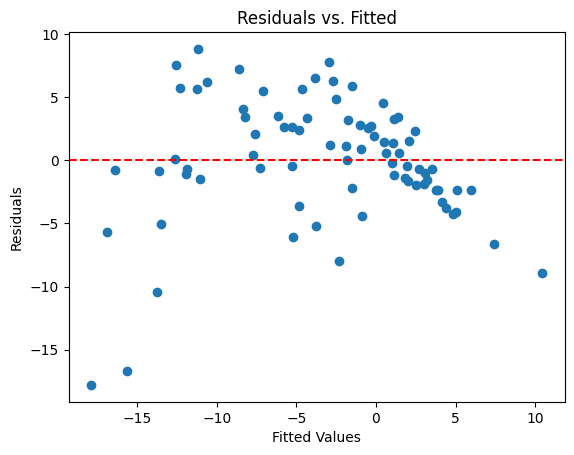

In [524]:
plt.scatter(model.fittedvalues, model.resid)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs. Fitted')
plt.show()

The residuals vs. fitted plot helps us see if the model assumptions about linearity and constant variance. In this plot, the residuals are scattered randomly around the horizontal line at zero, which is a good sign that the linearity assumption is mostly okay. However, I noticed that the spread of residuals isn’t entirely consistent as some areas show more clustering or variability than others, which could indicate that the variance isn’t constant. This doesn’t completely invalidate the model, but it’s something to keep in mind because it could mean that the predictions are less accurate in certain ranges.

2. QQ Plot of Residuals

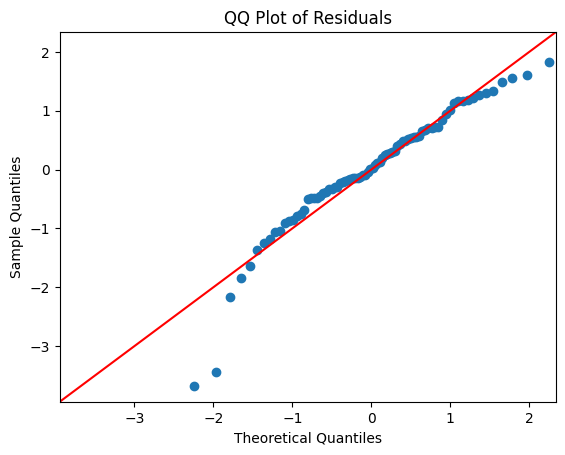

In [525]:
sm.qqplot(model.resid, line='45', fit=True)
plt.title("QQ Plot of Residuals")
plt.show()

The QQ plot is used to check if the residuals are normally distributed. Most of the points in this plot line up pretty well with the red diagonal line, which suggests that the normality assumption is reasonable. There are some minor deviations at the tails of the plot, meaning that the model may not perfectly capture outliers or extreme values, but overall it’s not a big issue. This supports the idea that the model’s results are reliable when it comes to making inferences about the data.

### e. Evaluate Model Performance

##### i. Variability Explained:

In [526]:
model.rsquared

0.6354135422156455

63.5% of the variability in weight change is explained by the model. This is a moderately high value, indicating a decent model fit.

##### ii. RMSE on Test Data:

In [527]:
y_pred = model.predict(test_data)
rmse = np.sqrt(mean_squared_error(test_data['Weight_Change'], y_pred))
rmse

4.413736460266025

The test RMSE is 4.41 pounds, indicating that, on average, the predicted weight change is off by about 4.41 pounds. In this case, the RMSE seems reasonable but could be improved.

## 3. Logistic Regression Analytical Tasks

### a. Research Question:
- How do physical activity levels, age, and stress level relate to the probability of having excellent sleep quality?

### b. Logistic Regression Model

##### i. Summary Output:

In [528]:
df1['Excellent_Sleep'] = (df1['Sleep_Quality'] == 'Excellent').astype(int)

In [529]:
train_data, test_data = train_test_split(df1, test_size=0.2, random_state=42)
model_logit = smf.logit('Excellent_Sleep ~ Age + Stress_Level + Physical_Activity_Level', data=train_data).fit()
print(model_logit.summary())

Optimization terminated successfully.
         Current function value: 0.400555
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:        Excellent_Sleep   No. Observations:                   80
Model:                          Logit   Df Residuals:                       74
Method:                           MLE   Df Model:                            5
Date:                Tue, 10 Dec 2024   Pseudo R-squ.:                 0.05241
Time:                        23:20:06   Log-Likelihood:                -32.044
converged:                       True   LL-Null:                       -33.817
Covariance Type:            nonrobust   LLR p-value:                    0.6166
                                                   coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------
Intercept                               

##### ii. Characteristics Associated with Higher Probability of Success:
- Physical Activity Level: None of the activity levels (Moderately Active, Sedentary, Very Active) were statistically significant predictors of excellent sleep quality.
- Age: Older participants are slightly more likely to report excellent sleep quality, with a small positive effect (coef = 0.0430), though not statistically significant (p = 0.119).
- Stress Level: Higher stress levels are associated with slightly lower odds of excellent sleep quality, but the effect is negligible and not significant (p = 0.941).

##### iii. Model Strength:

In [530]:
y_pred_prob = model_logit.predict(test_data)
auc = roc_auc_score(test_data['Excellent_Sleep'], y_pred_prob)
print(f"AUC: {auc}")

AUC: 0.734375


- Pseudo R-squared: 0.05241. This indicates that the model explains approximately 5.2% of the variability in the log-odds of achieving excellent sleep quality, which is low.
- AUC (Area Under the ROC Curve): 0.734375. This suggests moderate discrimination ability between those who achieve excellent sleep quality and those who do not.

### c. Build and Evaluate a Classifier

##### i. Building the Classifier:

In [531]:
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, classification_report

y_pred_class = (y_pred_prob >= 0.5).astype(int)

##### ii. Accuracy, Sensitivity, and Specificity:

In [532]:
accuracy = accuracy_score(test_data['Excellent_Sleep'], y_pred_class)

conf_matrix = confusion_matrix(test_data['Excellent_Sleep'], y_pred_class)

true_positive = conf_matrix[1, 1]
false_negative = conf_matrix[1, 0]
true_negative = conf_matrix[0, 0]
false_positive = conf_matrix[0, 1]
sensitivity = true_positive / (true_positive + false_negative)
specificity = true_negative / (true_negative + false_positive)

print(accuracy)
print(sensitivity)
print(specificity)

0.8
0.0
1.0


- Accuracy: 0.8 (80% of predictions were correct).
- Sensitivity: 0.0 (0% of those who actually achieved excellent sleep quality were correctly identified).
- Specificity: 1.0 (100% of those who did not achieve excellent sleep quality were correctly identified).

##### iii. Defining the Type of Error to Minimize:
Minimizing false negatives is critical in this context, as falsely predicting that someone will not achieve excellent sleep quality might lead to missed opportunities for interventions aimed at improving sleep.

##### iv. Satisfaction with Classifier Performance:
While the accuracy is relatively high at 80%, the classifier's inability to identify any true positives (sensitivity = 0) is concerning. This suggests that the model may be biased toward predicting the negative class and needs improvement, either through additional predictors, better tuning, or alternative modeling approaches.

## Any other type of analysis/question you want to explore with this dataset.

<u>Why?</u>: Sometimes undergraduate students will put the research projects that they did for their classes on their resumes when applying for graduate schools, internships, and jobs. If you're interested in showcasing cool analyses to write on your resume, this section could help with that. **(This section is not worth any points though).**

## 4. Conclusion

### a. Summarization
This project focused on predicting Weight Change and exploring factors related to Excellent Sleep. For the linear regression task, we found that Basal Metabolic Rate, Stress Level, Sleep Quality, Duration, and Daily Calories Consumed could explain 63.5% of the variation in weight change (R2 = 0.635). The test RMSE of 4.41 suggests the model has reasonable accuracy. Stress and sleep quality stood out as significant factors, as higher stress and poor sleep were strongly tied to greater weight changes. For logistic regression, we modeled Excellent Sleep and found that while the pseudo-R2 was low (0.05), the model performed reasonably well with an AUC of 0.73 and an 80% accuracy rate, showing it could somewhat identify factors linked to excellent sleep, such as activity level and stress.

### b. Limitations
One challenge was the dataset size as it only had 100 observations, which limits how well we can generalize these results to a broader population. Some variables, like Physical Activity Level, had unbalanced categories, which likely impacted how well the logistic model worked. Additionally, certain variables may have been too similar or multicollinear, such as Daily Calories Consumed and Basal Metabolic Rate, which could cause issues with interpreting their individual effects. Finally, the low pseudo-R2 in the logistic model suggests that other important factors affecting sleep quality might be missing from the dataset.

### c. Future Work
If this analysis were expanded, collecting more data from a larger and more diverse group of participants would be a great first step. Adding more detailed information, like types of exercise or specific sleep patterns, could make the models more useful. It might also be interesting to try different modeling approaches to see if they provide better predictions for sleep quality. Lastly, studying how these variables change over time, rather than just looking at snapshots, could give deeper insights into what drives weight change and sleep quality. Luckily, this project gives a foundational analysis to the topic and can be expanded upon easily with the necessary changes and improvements.